In [11]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [12]:
import os

ann_path = "/content/drive/MyDrive/PCB_PROJECT/PCB_DATASET/Annotations"
print(os.listdir(ann_path))

['Spurious_copper', 'Spur', 'Short', 'Open_circuit', 'Missing_hole', 'Mouse_bite']


Inspect one xml file

In [13]:
xml_file = "/content/drive/MyDrive/PCB_PROJECT/PCB_DATASET/Annotations/Spur/01_spur_16.xml"

tree = ET.parse(xml_file)
root = tree.getroot()

for obj in root.findall("object"):

    bbox = obj.find("bndbox")

    xmin = int(bbox.find("xmin").text)
    ymin = int(bbox.find("ymin").text)
    xmax = int(bbox.find("xmax").text)
    ymax = int(bbox.find("ymax").text)

    print("Bounding box:", xmin, ymin, xmax, ymax)

Bounding box: 2295 1289 2331 1328
Bounding box: 2129 980 2175 1020
Bounding box: 2419 1105 2467 1146


VISUALIZE BOUNDING BOXES

(np.float64(-0.5), np.float64(3033.5), np.float64(1585.5), np.float64(-0.5))

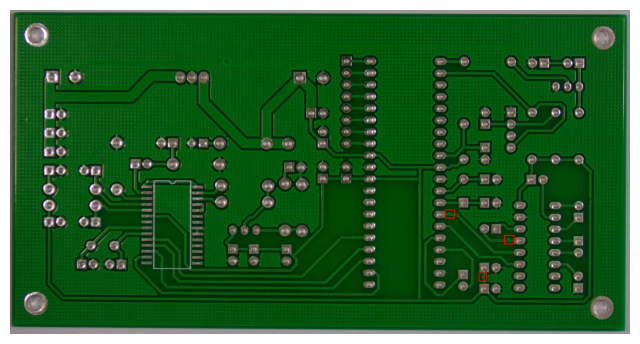

In [14]:
img_path = "/content/drive/MyDrive/PCB_PROJECT/PCB_DATASET/images/Spur/01_spur_16.jpg"

img = cv2.imread(img_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

for obj in root.findall("object"):

    bbox = obj.find("bndbox")

    xmin = int(bbox.find("xmin").text)
    ymin = int(bbox.find("ymin").text)
    xmax = int(bbox.find("xmax").text)
    ymax = int(bbox.find("ymax").text)

    cv2.rectangle(img,(xmin,ymin),(xmax,ymax),(255,0,0),3)

plt.figure(figsize=(8,8))
plt.imshow(img)
plt.axis("off")

**ROI - TEST**

```
**# This is formatted as code**
```



In [15]:
roi_folder = "/content/drive/MyDrive/PCB_PROJECT/outputs/roi_test"

os.makedirs(roi_folder, exist_ok=True)

roi_count = 0
padding = 20

for obj in root.findall("object"):

    bbox = obj.find("bndbox")

    xmin = int(bbox.find("xmin").text)
    ymin = int(bbox.find("ymin").text)
    xmax = int(bbox.find("xmax").text)
    ymax = int(bbox.find("ymax").text)

    xmin_p = max(0, xmin-padding)
    ymin_p = max(0, ymin-padding)
    xmax_p = min(img.shape[1], xmax+padding)
    ymax_p = min(img.shape[0], ymax+padding)

    roi = img[ymin_p:ymax_p, xmin_p:xmax_p]

    roi_file = f"spur_roi_{roi_count}.jpg"

    cv2.imwrite(os.path.join(roi_folder,roi_file),cv2.cvtColor(roi,cv2.COLOR_RGB2BGR))

    roi_count += 1

**ROI EXTRACT- FULL DATASET**

In [16]:
DATASET_PATH = "/content/drive/MyDrive/PCB_PROJECT/PCB_DATASET"

images_path = os.path.join(DATASET_PATH,"images")
ann_path = os.path.join(DATASET_PATH,"Annotations")

output_base = "/content/drive/MyDrive/PCB_PROJECT/outputs/roi_images"

padding = 20

for defect_class in os.listdir(ann_path):

    ann_folder = os.path.join(ann_path,defect_class)

    if not os.path.isdir(ann_folder):
        continue

    print("Processing:",defect_class)

    class_output = os.path.join(output_base,defect_class)
    os.makedirs(class_output,exist_ok=True)

    for xml_file in os.listdir(ann_folder):

        xml_path = os.path.join(ann_folder,xml_file)

        tree = ET.parse(xml_path)
        root = tree.getroot()

        img_name = xml_file.replace(".xml",".jpg")

        img_path = os.path.join(images_path,defect_class,img_name)

        img = cv2.imread(img_path)

        roi_count = 0

        for obj in root.findall("object"):

            bbox = obj.find("bndbox")

            xmin = int(bbox.find("xmin").text)
            ymin = int(bbox.find("ymin").text)
            xmax = int(bbox.find("xmax").text)
            ymax = int(bbox.find("ymax").text)

            xmin_p = max(0,xmin-padding)
            ymin_p = max(0,ymin-padding)
            xmax_p = min(img.shape[1],xmax+padding)
            ymax_p = min(img.shape[0],ymax+padding)

            roi = img[ymin_p:ymax_p,xmin_p:xmax_p]

            roi_file = xml_file.replace(".xml",f"_roi_{roi_count}.jpg")

            cv2.imwrite(os.path.join(class_output,roi_file),roi)

            roi_count += 1

print("Full ROI extraction completed")

Processing: Spurious_copper
Processing: Spur
Processing: Short
Processing: Open_circuit
Processing: Missing_hole
Processing: Mouse_bite
Full ROI extraction completed


roi image count and size

In [17]:
import os

roi_path = "/content/drive/MyDrive/PCB_PROJECT/outputs/roi_images"

for defect_class in os.listdir(roi_path):

    class_path = os.path.join(roi_path, defect_class)

    if os.path.isdir(class_path):
        count = len(os.listdir(class_path))
        print(defect_class, ":", count)

Spurious_copper : 503
Spur : 488
Short : 491
Open_circuit : 482
Missing_hole : 497
Mouse_bite : 492


In [18]:
import cv2
import os

sample_path = "/content/drive/MyDrive/PCB_PROJECT/outputs/roi_images/Spur"

sample_img = os.listdir(sample_path)[0]

img = cv2.imread(os.path.join(sample_path, sample_img))

print(img.shape)

(79, 76, 3)
